# K-Means Clustering

## Importing the libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas_gbq
import pandas as pd
import sklearn
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [4]:
#Adv Stats

## Importing the dataset

In [5]:
#Change the date to the previous day
query_adv = """
SELECT 
*
FROM `perceptive-ivy-290216.ncaab.player_stats_adv_freshman`
# WHERE SEASON='2022-23'
"""
project_id = "perceptive-ivy-290216"
player_stats_adv = pandas_gbq.read_gbq(query_adv, project_id=project_id, dialect='standard')
player_stats_adv=player_stats_adv.fillna(0)

Downloading: 100%|██████████|


In [20]:
# dataset=player_stats[(player_stats['W']>10)&(player_stats['MIN']>0)]
dataset=player_stats_adv
dataset=dataset[['Player', 'Team', 'Season','TSPERCENT', 'EFGPERCENT', 'TOTALS%',
       'ORBPERCENT', 'DRBPERCENT', 'TRBPERCENT', 'ASTPERCENT', 'TOVPERCENT',
       'STLPERCENT', 'BLKPERCENT', 'USGPERCENT', 'PPR', 'PPS', 'ORTG', 'DRTG',
       'EDIFF', 'FIC', 'PER']]
dataset.head()

,Player,Team,Season,TSPERCENT,EFGPERCENT,TOTALS%,ORBPERCENT,DRBPERCENT,TRBPERCENT,ASTPERCENT,...,STLPERCENT,BLKPERCENT,USGPERCENT,PPR,PPS,ORTG,DRTG,EDIFF,FIC,PER
0,Matt Reed,TULSA,2024,.525,.491,140.6,9.6,21.7,15.9,5.4,...,0.3,1.3,15.7,-2.6,1.2,105.8,103.5,2.3,117.4,11.4
1,Josh Pascarelli,MRST,2024,.551,.545,146.9,1.0,13.0,7.2,12.0,...,0.4,0.3,22.5,-1.2,1.1,102.5,100.6,1.8,172.3,13.4
2,Jordan Pennick,USNA,2024,.404,.371,128.3,4.8,14.1,9.2,1.8,...,0.5,0.7,17.0,-2.8,0.9,87.7,105.1,-17.4,29.3,5.2
3,Jaiden Thompson,CHASO,2024,.451,.407,126.4,1.3,10.2,5.7,14.6,...,0.5,0.5,13.1,-2.3,1.1,79.7,111.1,-31.4,20.5,3.0
4,Rihards Vavers,QUIN,2024,.559,.513,162.2,3.2,15.8,9.6,6.9,...,0.5,2.5,21.5,-1.0,1.3,116.7,103.2,13.5,117.0,16.4


In [21]:
# X = dataset.iloc[:,3:].values
X = dataset.loc[:,['TSPERCENT', 'EFGPERCENT', 'TOTALS%',
       'ORBPERCENT', 'DRBPERCENT', 'TRBPERCENT', 'ASTPERCENT', 'TOVPERCENT',
       'STLPERCENT', 'BLKPERCENT', 'USGPERCENT', 'PPR', 'PPS', 'ORTG', 'DRTG',
       'EDIFF', 'FIC', 'PER']].values
X

array([['.525', '.491', '140.6', ..., '2.3', '117.4', '11.4'],
       ['.551', '.545', '146.9', ..., '1.8', '172.3', '13.4'],
       ['.404', '.371', '128.3', ..., '-17.4', '29.3', '5.2'],
       ...,
       ['.489', '.491', '118.6', ..., '19.6', '110.4', '17.4'],
       ['.591', '.588', '138.9', ..., '5.8', '327.5', '27.6'],
       ['.575', '.521', '155.7', ..., '21.2', '206.5', '21.3']],
      dtype=object)

In [22]:
dataset_2=dataset.iloc[:,2:]
scaler=StandardScaler()
segmentation_std_adv=scaler.fit_transform(dataset_2)
dataset_2

,Season,TSPERCENT,EFGPERCENT,TOTALS%,ORBPERCENT,DRBPERCENT,TRBPERCENT,ASTPERCENT,TOVPERCENT,STLPERCENT,BLKPERCENT,USGPERCENT,PPR,PPS,ORTG,DRTG,EDIFF,FIC,PER
0,2024,.525,.491,140.6,9.6,21.7,15.9,5.4,14.7,0.3,1.3,15.7,-2.6,1.2,105.8,103.5,2.3,117.4,11.4
1,2024,.551,.545,146.9,1.0,13.0,7.2,12.0,11.5,0.4,0.3,22.5,-1.2,1.1,102.5,100.6,1.8,172.3,13.4
2,2024,.404,.371,128.3,4.8,14.1,9.2,1.8,9.8,0.5,0.7,17.0,-2.8,0.9,87.7,105.1,-17.4,29.3,5.2
3,2024,.451,.407,126.4,1.3,10.2,5.7,14.6,29.2,0.5,0.5,13.1,-2.3,1.1,79.7,111.1,-31.4,20.5,3.0
4,2024,.559,.513,162.2,3.2,15.8,9.6,6.9,8.1,0.5,2.5,21.5,-1.0,1.3,116.7,103.2,13.5,117.0,16.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8687,2025,.561,.515,160.2,8.4,8.5,8.5,11.2,11.4,4.6,1.4,25.5,-2.1,1.3,116.8,96.9,19.9,197.6,22.2
8688,2025,.535,.513,146.9,2.6,11.4,6.8,16.3,7.2,4.8,0.9,13.9,4.2,1.2,122.0,102.6,19.4,188.3,16.6
8689,2025,.489,.491,118.6,11.1,15.5,13.3,12.0,10.9,4.9,3.0,20.1,0.0,1.1,110.2,90.5,19.6,110.4,17.4
8690,2025,.591,.588,138.9,7.7,20.7,14.2,14.0,14.7,5.0,3.2,32.3,-5.5,1.4,107.9,102.0,5.8,327.5,27.6


In [23]:
pca=PCA()
pca.fit(segmentation_std_adv)

PCA()

In [24]:
pd.set_option('display.float_format', '{:.2f}'.format)
pd.DataFrame(pca.explained_variance_ratio_)

,0
0,0.36
1,0.19
2,0.10
3,0.07
4,0.07
5,0.05
6,0.04
7,0.03
8,0.03
9,0.02


## Using the elbow method to find the optimal number of clusters

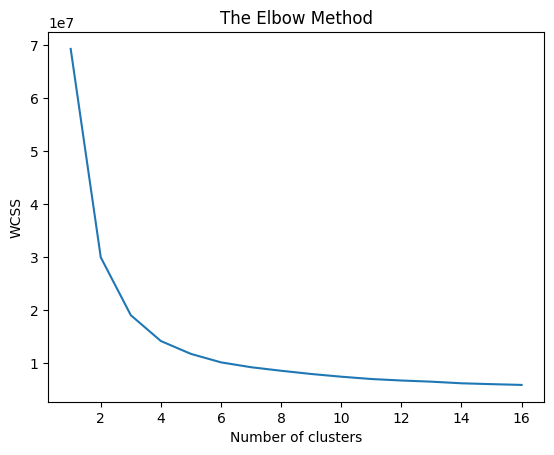

In [25]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 17):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 17), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

## Training the K-Means model on the dataset

In [26]:
kmeans = KMeans(n_clusters = 12, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)
y_kmeans

array([ 9,  0, 10, ...,  6,  1,  7], dtype=int32)

In [27]:
cluster_0=dataset[y_kmeans==0].copy()
cluster_0["cluster"]="cluster_0"
cluster_1=dataset[y_kmeans==1].copy()
cluster_1["cluster"]="cluster_1"
cluster_2=dataset[y_kmeans==2].copy()
cluster_2["cluster"]="cluster_2"
cluster_3=dataset[y_kmeans==3].copy()
cluster_3["cluster"]="cluster_3"
cluster_4=dataset[y_kmeans==4].copy()
cluster_4["cluster"]="cluster_4"
cluster_5=dataset[y_kmeans==5].copy()
cluster_5["cluster"]="cluster_5"
cluster_6=dataset[y_kmeans==6].copy()
cluster_6["cluster"]="cluster_6"
cluster_7=dataset[y_kmeans==7].copy()
cluster_7["cluster"]="cluster_7"
cluster_8=dataset[y_kmeans==8].copy()
cluster_8["cluster"]="cluster_8"
cluster_9=dataset[y_kmeans==9].copy()
cluster_9["cluster"]="cluster_9"
cluster_10=dataset[y_kmeans==10].copy()
cluster_10["cluster"]="cluster_10"
cluster_11=dataset[y_kmeans==11].copy()
cluster_11["cluster"]="cluster_11"
cluster_12=dataset[y_kmeans==12].copy()
cluster_12["cluster"]="cluster_12"
cluster_final=pd.concat([cluster_0, cluster_1, cluster_2, cluster_3, cluster_4, cluster_5, cluster_6, cluster_7, cluster_8, cluster_9,
                         cluster_10, cluster_11, cluster_12], ignore_index=True)
cluster_final.tail()

,Player,Team,Season,TSPERCENT,EFGPERCENT,TOTALS%,ORBPERCENT,DRBPERCENT,TRBPERCENT,ASTPERCENT,...,BLKPERCENT,USGPERCENT,PPR,PPS,ORTG,DRTG,EDIFF,FIC,PER,cluster
8687,Corey Chest,LSU,2025,.584,.607,105.6,15.1,23.7,19.6,6.8,...,6.1,16.0,-3.5,1.4,113.1,97.3,15.8,211.1,19.3,cluster_11
8688,Luke Bamgboye,VCU,2025,.587,.595,111.2,11.3,12.3,11.8,5.3,...,14.9,11.7,-2.7,1.4,114.8,88.8,26.0,168.4,17.5,cluster_11
8689,Ryan Kalambay,UDM,2025,.536,.530,106.2,10.8,14.7,12.7,6.9,...,5.6,11.7,-2.4,1.4,105.1,106.8,-1.6,140.6,12.5,cluster_11
8690,Ryan Mela,PROV,2025,.500,.479,130.8,6.1,27.6,17.1,18.5,...,0.8,20.1,-0.4,1.2,103.2,102.8,0.4,179.9,16.0,cluster_11
8691,Zavier Fitch,WAGNR,2025,.547,.516,121.9,9.2,18.0,13.3,7.9,...,3.9,12.7,-1.0,1.4,113.6,94.4,19.2,157.0,14.6,cluster_11


In [28]:
cluster_final

,Player,Team,Season,TSPERCENT,EFGPERCENT,TOTALS%,ORBPERCENT,DRBPERCENT,TRBPERCENT,ASTPERCENT,...,BLKPERCENT,USGPERCENT,PPR,PPS,ORTG,DRTG,EDIFF,FIC,PER,cluster
0,Josh Pascarelli,MRST,2024,.551,.545,146.9,1.0,13.0,7.2,12.0,...,0.3,22.5,-1.2,1.1,102.5,100.6,1.8,172.3,13.4,cluster_0
1,Tyler Tejada,TOWS,2024,.534,.493,161.2,3.4,14.5,8.9,7.4,...,2.0,24.1,-3.9,1.2,109.9,102.5,7.4,169.0,15.5,cluster_0
2,Bol Dengdit,UP,2024,.512,.475,136.3,8.3,20.2,14.3,6.7,...,0.7,17.0,-1.0,1.2,107.8,115.0,-7.1,162.3,13.0,cluster_0
3,Braeden Shrewsberry,ND,2024,.551,.533,159.3,0.5,10.2,5.5,7.2,...,0.1,20.1,-2.1,1.2,105.7,106.5,-0.8,161.5,12.3,cluster_0
4,Sam Brown,PENN,2024,.611,.584,170.3,1.6,11.2,6.4,12.0,...,0.8,18.1,0.4,1.3,119.3,115.5,3.8,178.6,15.2,cluster_0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8687,Corey Chest,LSU,2025,.584,.607,105.6,15.1,23.7,19.6,6.8,...,6.1,16.0,-3.5,1.4,113.1,97.3,15.8,211.1,19.3,cluster_11
8688,Luke Bamgboye,VCU,2025,.587,.595,111.2,11.3,12.3,11.8,5.3,...,14.9,11.7,-2.7,1.4,114.8,88.8,26.0,168.4,17.5,cluster_11
8689,Ryan Kalambay,UDM,2025,.536,.530,106.2,10.8,14.7,12.7,6.9,...,5.6,11.7,-2.4,1.4,105.1,106.8,-1.6,140.6,12.5,cluster_11
8690,Ryan Mela,PROV,2025,.500,.479,130.8,6.1,27.6,17.1,18.5,...,0.8,20.1,-0.4,1.2,103.2,102.8,0.4,179.9,16.0,cluster_11


In [29]:
cluster_final[cluster_final["Player"]=='V.J. Edgecombe']

,Player,Team,Season,TSPERCENT,EFGPERCENT,TOTALS%,ORBPERCENT,DRBPERCENT,TRBPERCENT,ASTPERCENT,...,BLKPERCENT,USGPERCENT,PPR,PPS,ORTG,DRTG,EDIFF,FIC,PER,cluster
6315,V.J. Edgecombe,BAYL,2025,.556,.511,157.5,7.4,14.1,10.7,19.7,...,2.3,24.2,0.5,1.3,118.3,98.2,20.1,348.3,22.4,cluster_8


In [32]:
cluster_final["TSPERCENT"]=cluster_final["TSPERCENT"].astype(float)
cluster_final["PER"]=cluster_final["PER"].astype(float)

## Visualising the clusters

In [35]:
fig=px.scatter(cluster_final, 
               x="TSPERCENT",
               y="PER", 
               color='cluster',
               hover_data=['Player','TSPERCENT', 'EFGPERCENT', 'TOTALS%',
       'ORBPERCENT', 'DRBPERCENT', 'TRBPERCENT', 'ASTPERCENT', 'TOVPERCENT',
       'STLPERCENT', 'BLKPERCENT', 'USGPERCENT', 'PPR', 'PPS', 'ORTG', 'DRTG',
       'EDIFF', 'FIC', 'PER'],
               height=700, 
               width=900,
        )

# fig2=px.scatter(Final[Final['value']==1], x="POINTS_PER_MIN_", y="CATCH_SHOOT_FGM_", color_discrete_sequence=['blue'],
#         hover_data=["PLAYER_NAME","Salary"],
#         height=700, width=900,
#         )

# fig3=px.scatter(Final[Final['value']==2], x="POINTS_PER_MIN_", y="CATCH_SHOOT_FGM_", color_discrete_sequence=['orange'],
#         hover_data=["PLAYER_NAME","Salary"],
#         height=700, width=900,
#         )
# fig4=px.scatter(kmeans.cluster_centers_, kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:, 0], color_discrete_sequence=['yellow'],
#         height=1000, width=1000,
#         )
# fig4.update_traces(marker=dict(size=20))

# fig.add_traces(
#     list(fig2.select_traces())
# )

# fig.add_traces(
#     list(fig3.select_traces())
# )

# fig.add_traces(
#     list(fig4.select_traces())
# )

# fig.update_layout(
#     xaxis_title="MIN",
#     yaxis_title="FGA",
#     # xaxis_range=[0,1]
# )

fig.show()

In [37]:
cluster_final[cluster_final["cluster"]=='cluster_8'].to_csv("adv_cluster.csv")